# Fase 4: Optimización y Selección de Características (Feature Selection)

**Objetivo de este Notebook:**
En la fase anterior demostramos que los modelos alcanzan precisiones casi perfectas. Sin embargo, procesar más de 200 variables matemáticas en tiempo real en un hardware industrial (*Edge Computing*) es computacionalmente costoso y poco eficiente.

En esta fase, aplicaremos técnicas de reducción de dimensionalidad para encontrar el número mínimo de características necesarias para mantener la precisión operativa. Dividiremos el proceso en dos etapas:
1. **Pre-filtrado por Correlación:** Eliminación estadística de variables redundantes.
2. **Sequential Backward Selection (SBS):** Algoritmo envolvente que elimina iterativamente las características que menos aportan al rendimiento del modelo.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, mean_squared_error, mean_absolute_error, r2_score
from mlxtend.feature_selection import SequentialFeatureSelector as sfs
import joblib
import os
import json

In [4]:
def filtro_correlacion(df_path, threshold=0.9):
    df = pd.read_csv(df_path)
    correlation_matrix = df.drop(columns=['clase', 'subclase', 'file_path']).corr()
    
    # Filtrar correlaciones absolutas mayores al threshold
    high_correlation_matrix = correlation_matrix[(correlation_matrix.abs() > threshold) & (correlation_matrix.abs() < 1.0)]
    
    selected_variables = set()
    for col in high_correlation_matrix.columns:
        for row in high_correlation_matrix.index:
            if not np.isnan(high_correlation_matrix.loc[row, col]):
                selected_variables.add(col)
                break
                
    variables_a_eliminar = list(selected_variables)
    df_reducido = df.drop(columns=variables_a_eliminar)
    print(f"[{os.path.basename(df_path)}] Variables eliminadas por correlación (> {threshold}): {len(variables_a_eliminar)}")
    print(f"[{os.path.basename(df_path)}] Variables restantes: {df_reducido.shape[1] - 3}")
    return df_reducido

reduced_time = filtro_correlacion('../../Datos/Transformados/features_dom_tiempo.csv')
reduced_freq = filtro_correlacion('../../Datos/Transformados/features_dom_frecuencia.csv')

[features_dom_tiempo.csv] Variables eliminadas por correlación (> 0.9): 21
[features_dom_tiempo.csv] Variables restantes: 21
[features_dom_frecuencia.csv] Variables eliminadas por correlación (> 0.9): 5
[features_dom_frecuencia.csv] Variables restantes: 16


## 2. Optimización Algorítmica: Sequential Backward Selection (SBS)
**¿Por qué utilizamos una selección hacia atrás (Backward) en lugar de hacia adelante (Forward)?**
En el diagnóstico de vibraciones, las características a menudo interactúan entre sí de forma compleja (por ejemplo, un pico en una frecuencia solo es relevante si la energía total RMS también sube). El enfoque *Backward* comienza con el modelo evaluando todo el contexto global y va "podando" las variables inútiles. Esto preserva las interacciones ocultas mucho mejor que si construyéramos el modelo variable a variable desde cero.

In [5]:
def backward_feature_selection(df, nombre_dominio):
    X = df.drop(columns=['clase', 'subclase', 'file_path'])
    y = df['clase']
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
    
    # Modelo Base para comparar
    rf_base = RandomForestClassifier(n_estimators=100, random_state=42)
    rf_base.fit(X_train, y_train)
    acc_base = accuracy_score(y_test, rf_base.predict(X_test))
    print(f"\n--- Ejecutando SBS para {nombre_dominio} ---")
    print(f"Precisión antes de SBS: {acc_base:.4f}")
    
    # Selector
    sfs_selector = sfs(RandomForestClassifier(n_estimators=100, random_state=42),
                       k_features='best',
                       forward=False, # Backward
                       floating=False,
                       verbose=0,     # Pon a 2 si quieres ver el proceso paso a paso
                       scoring='accuracy',
                       cv=5,
                       n_jobs=-1)     # Usa todos los núcleos disponibles
    
    sfs_selector.fit(X_train, y_train)
    mejores_vars = list(sfs_selector.k_feature_names_)
    print(f"Características óptimas finales: {len(mejores_vars)}")
    
    # GUARDAMOS CONSERVANDO LAS ETIQUETAS Y FILE_PATH
    df_optimo = df[mejores_vars + ['clase', 'subclase', 'file_path']]
    df_optimo.to_csv(f'../../Datos/Transformados/best_{nombre_dominio}_features.csv', index=False)
    return df_optimo

# Ejecutamos el SBS (Esto puede tardar unos minutos)
best_time_features = backward_feature_selection(reduced_time, "time")
best_frequency_features = backward_feature_selection(reduced_freq, "frequency")

# Creamos el Híbrido Optimizado gracias a que conservamos el file_path
best_freq_reduced = best_frequency_features.drop(columns=['clase', 'subclase'])
best_hybrid_features = pd.merge(best_time_features, best_freq_reduced, on='file_path')


--- Ejecutando SBS para time ---
Precisión antes de SBS: 0.9676
Características óptimas finales: 20

--- Ejecutando SBS para frequency ---
Precisión antes de SBS: 0.9556
Características óptimas finales: 11


## 3. Validación del Sistema Optimizado (Regresión Especialista)
Una vez reducida drásticamente la dimensionalidad del problema, el paso final es validar que nuestros modelos especialistas (Regresores) siguen siendo capaces de predecir la severidad física del fallo (mm o gramos) con una precisión aceptable para la industria.

A continuación re-entrenamos la arquitectura completa utilizando **únicamente las variables óptimas**.

=== EVALUACIÓN OPTIMIZADA: TIEMPO ===


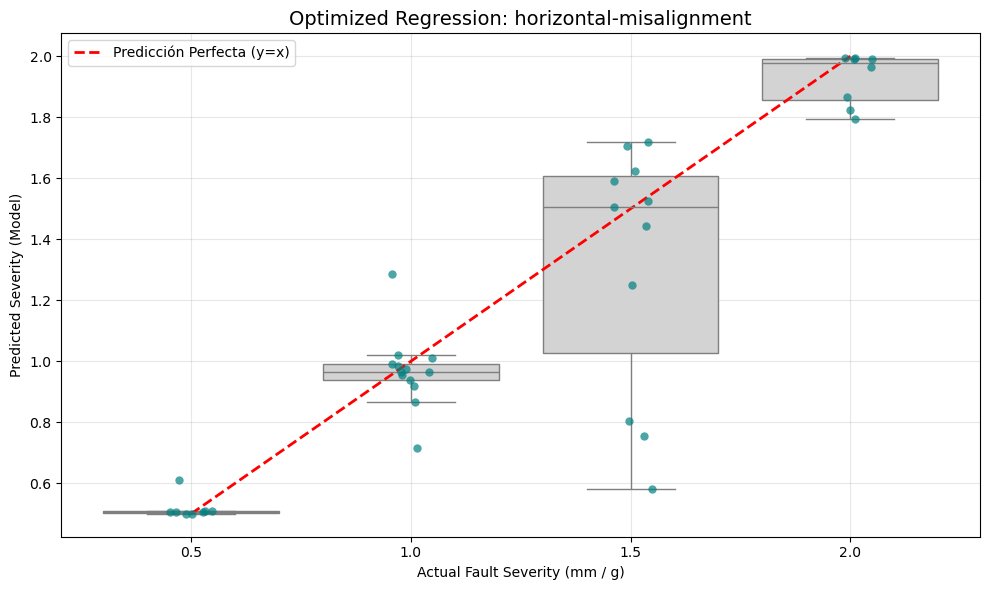

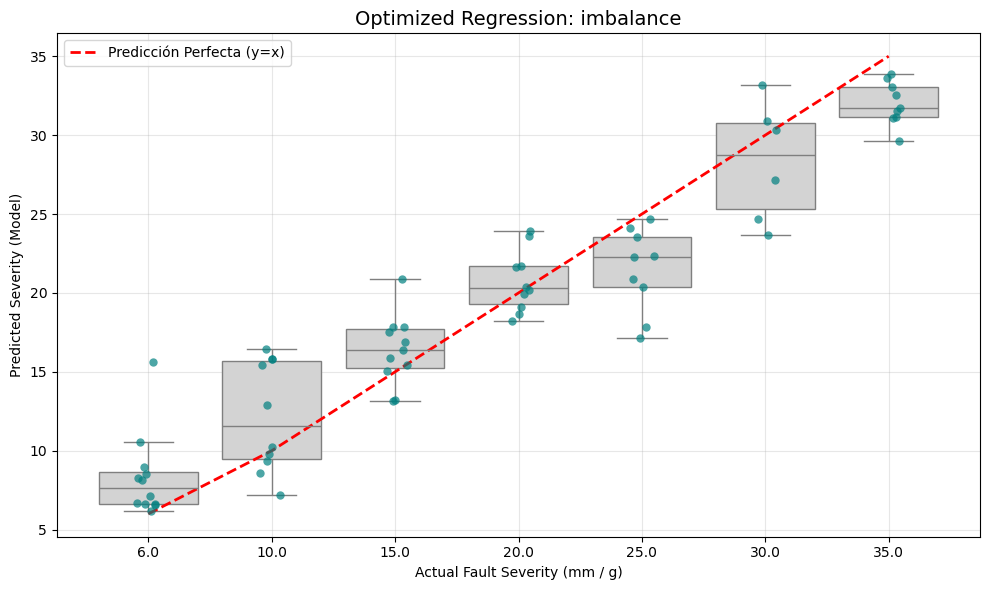

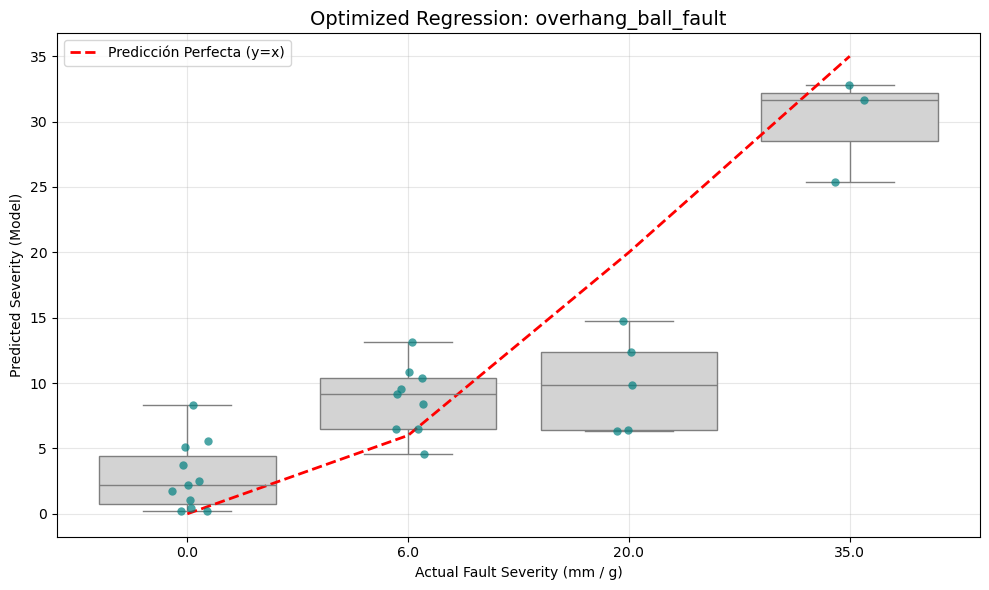

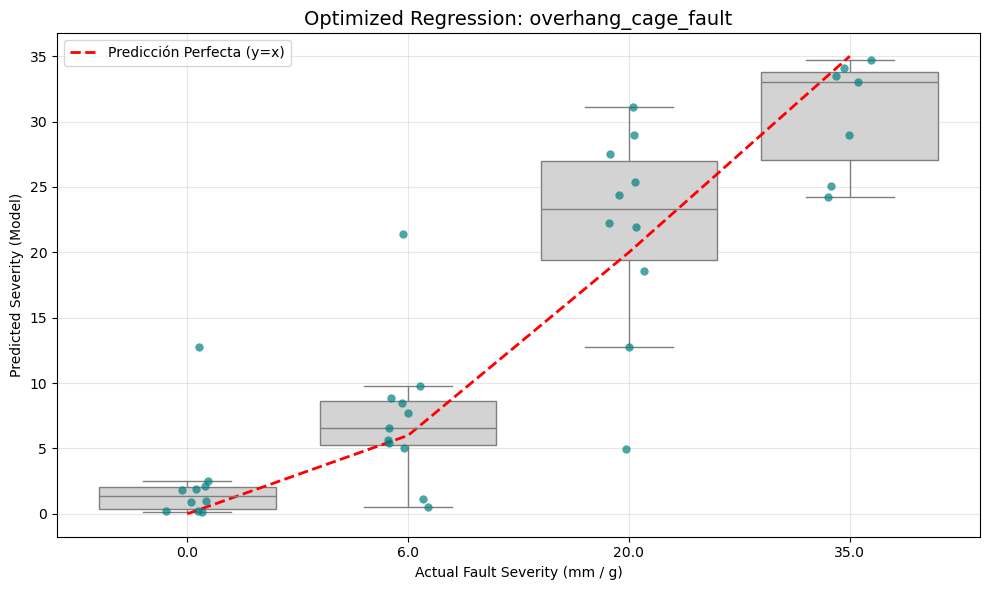

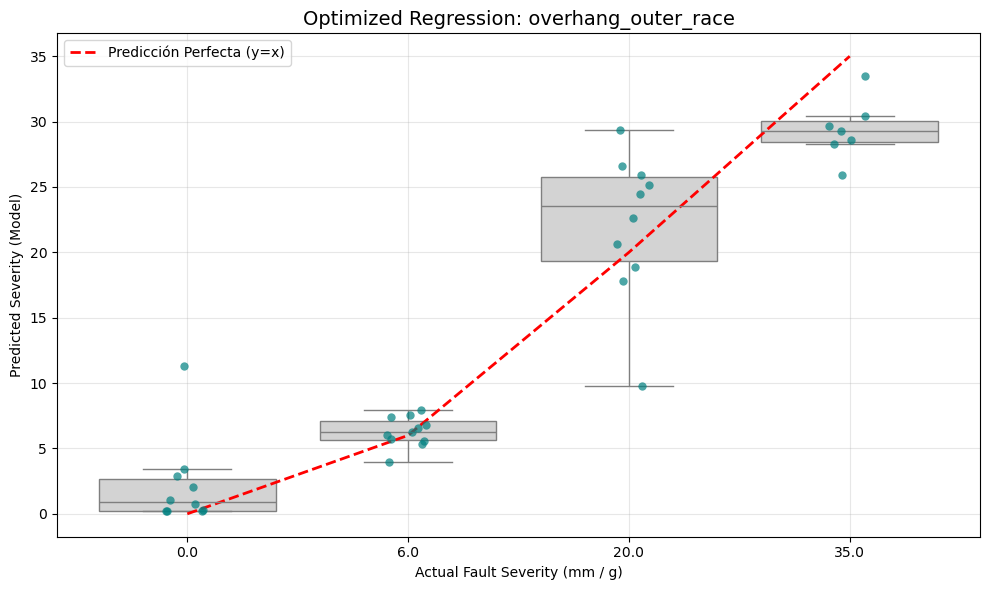

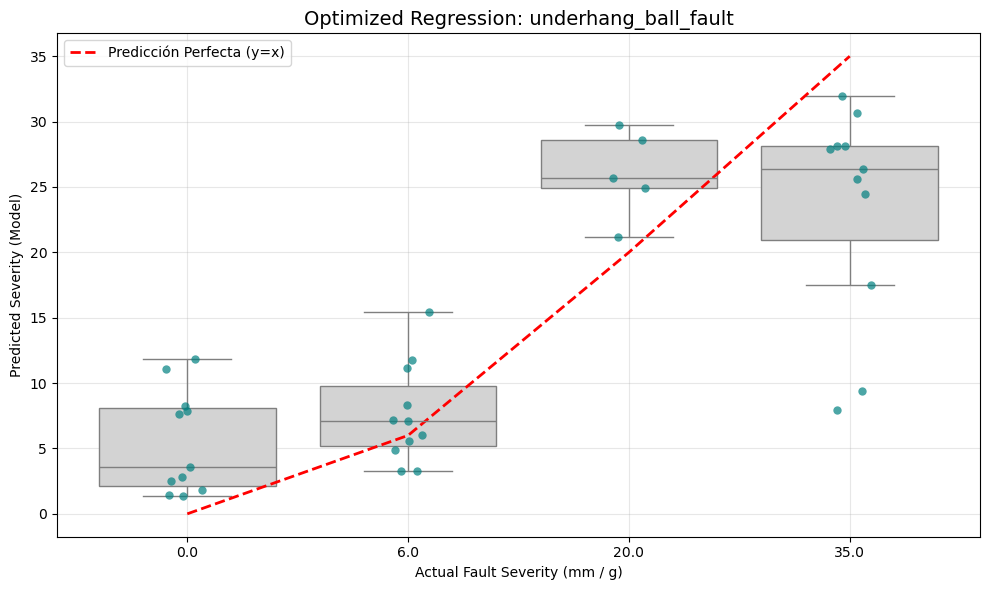

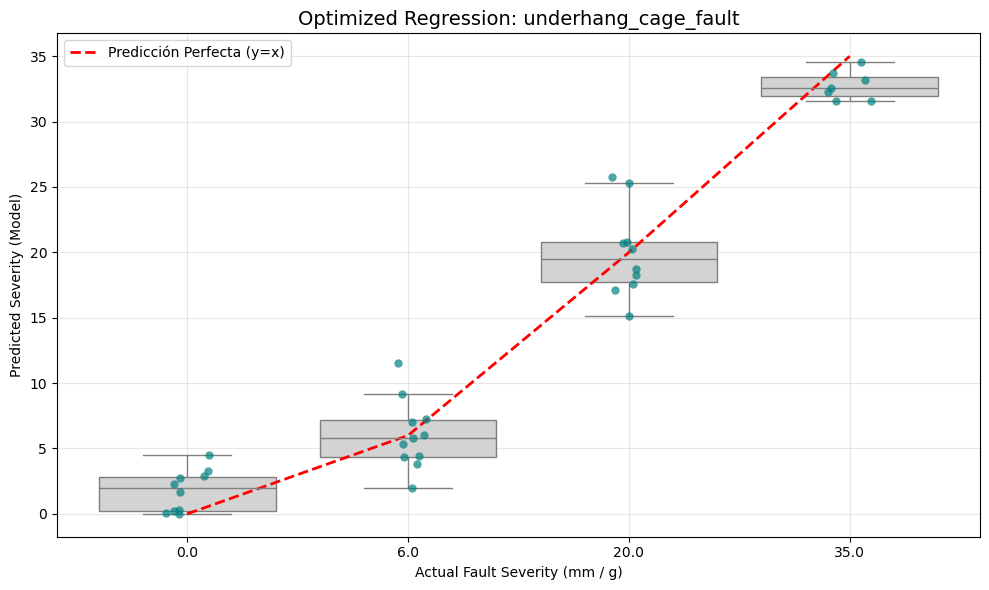

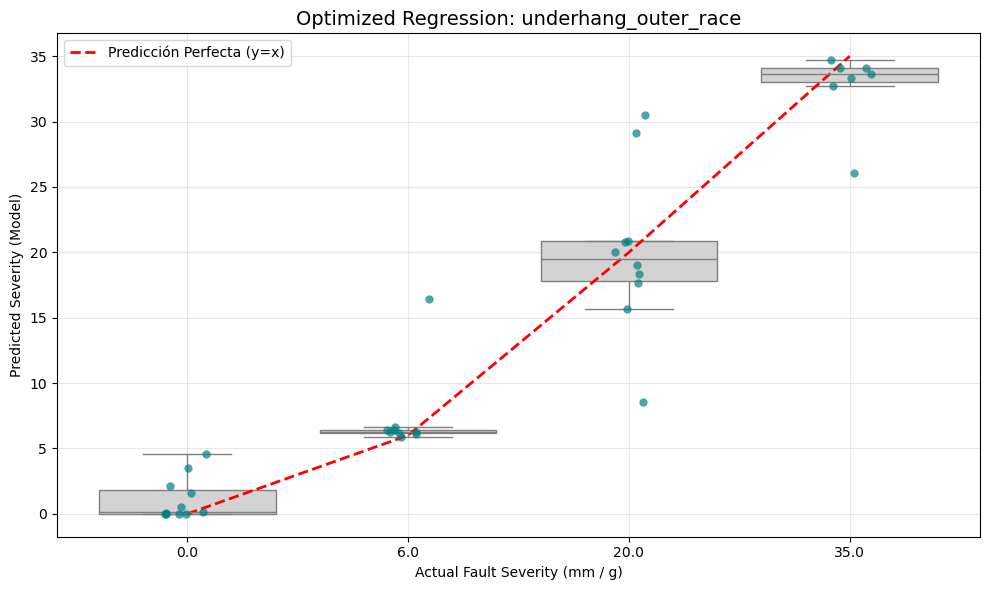

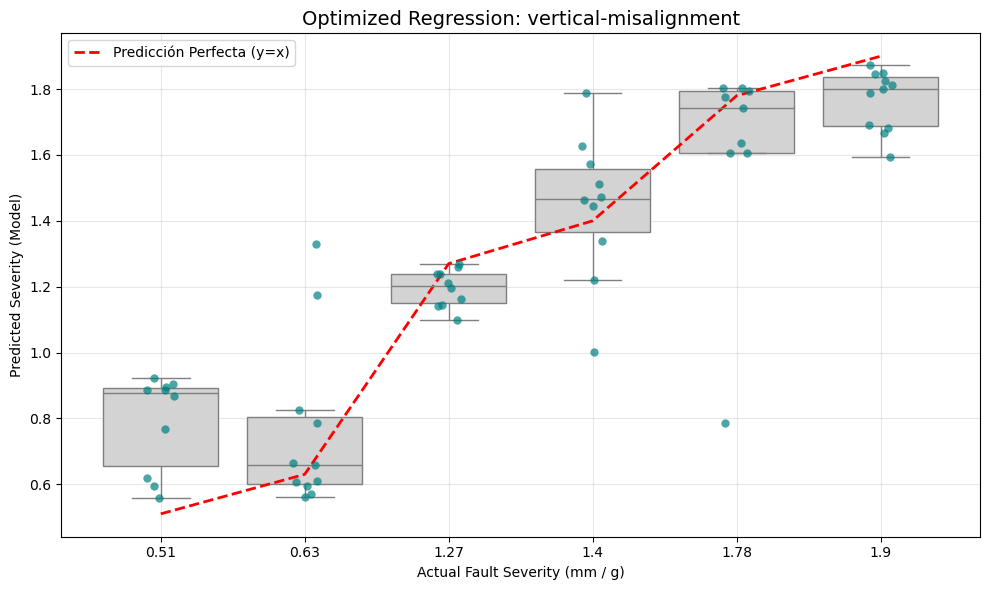

=== EVALUACIÓN OPTIMIZADA: FRECUENCIA ===


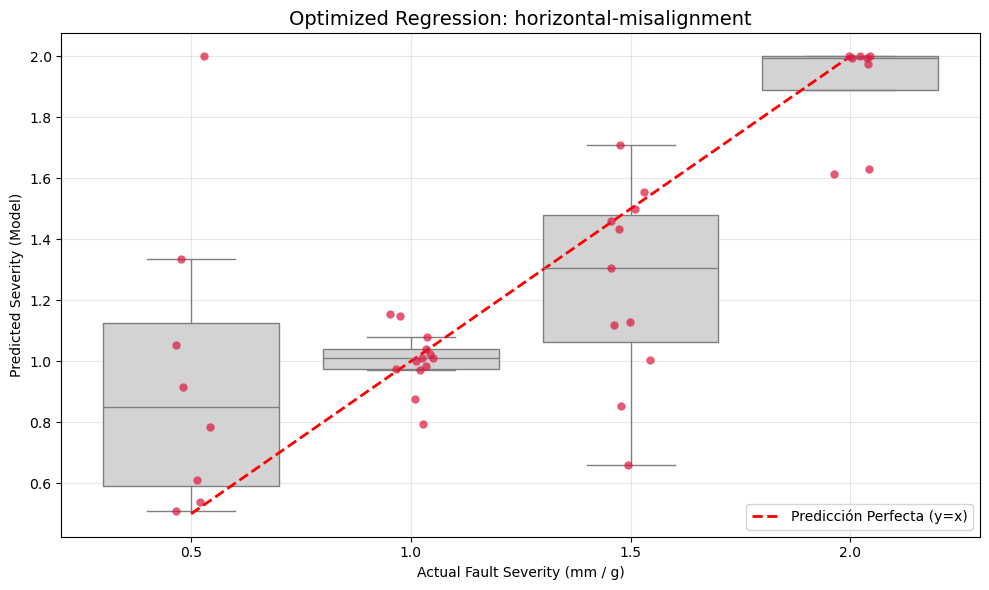

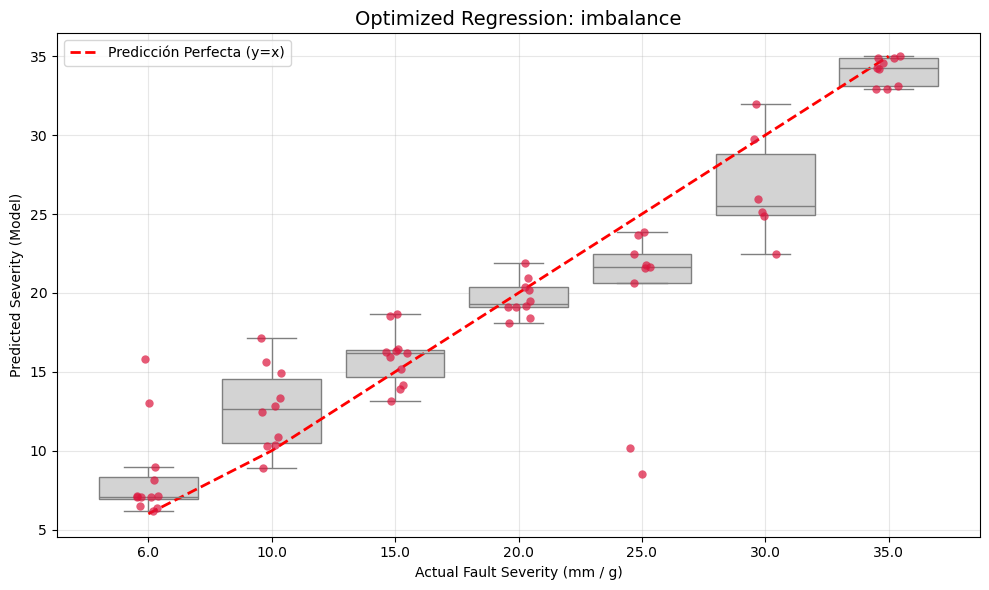

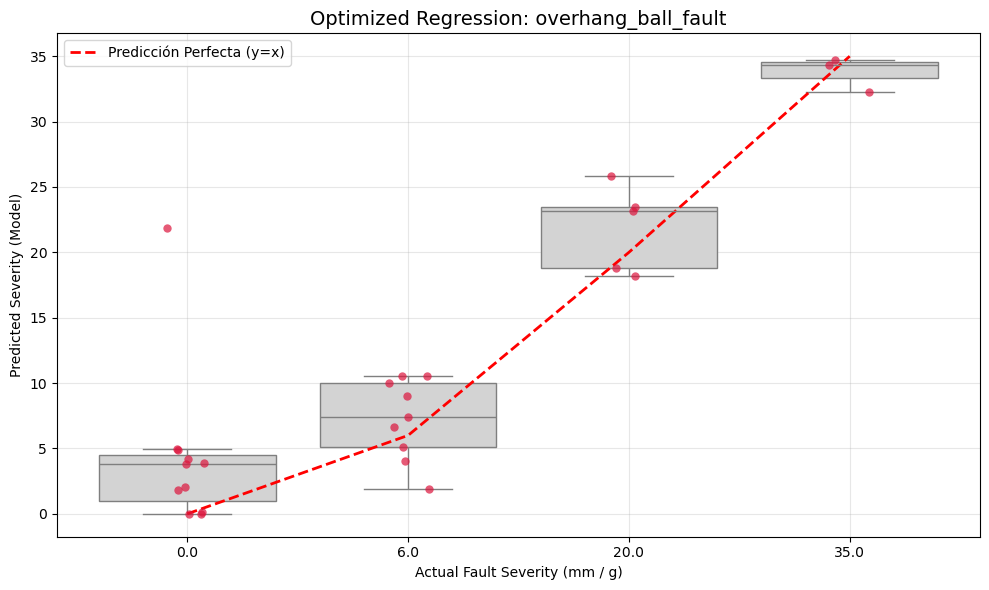

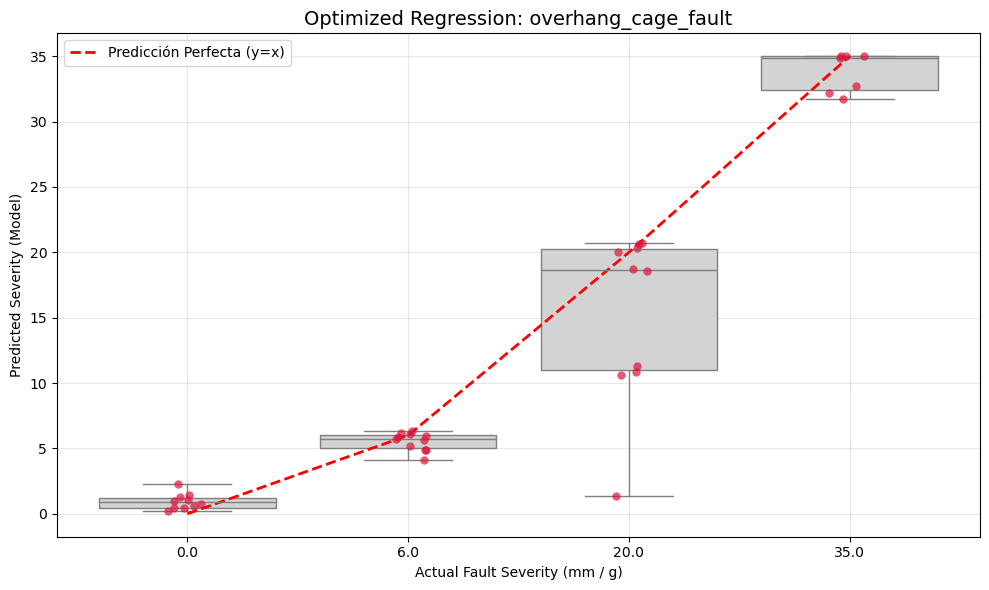

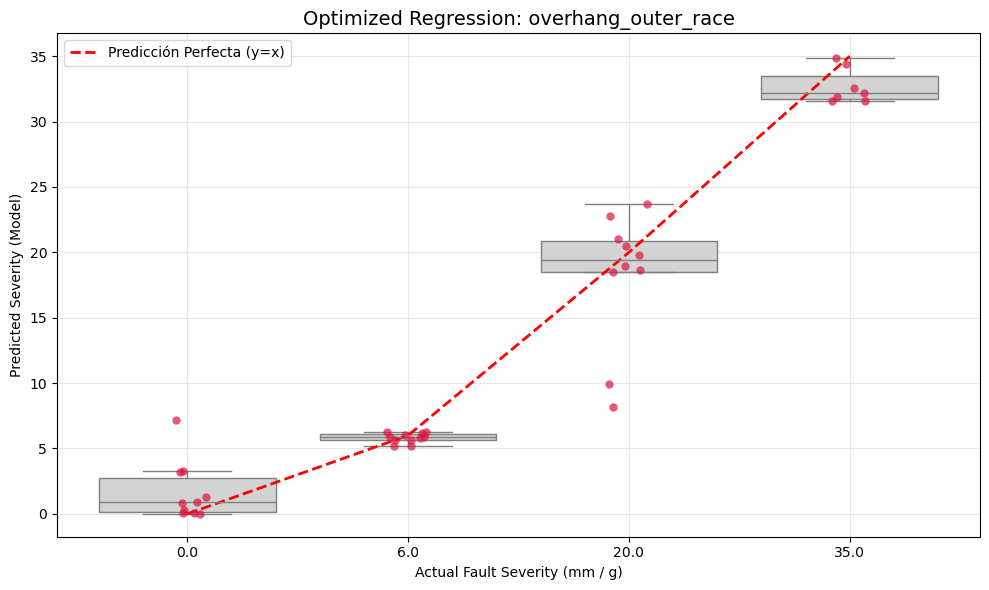

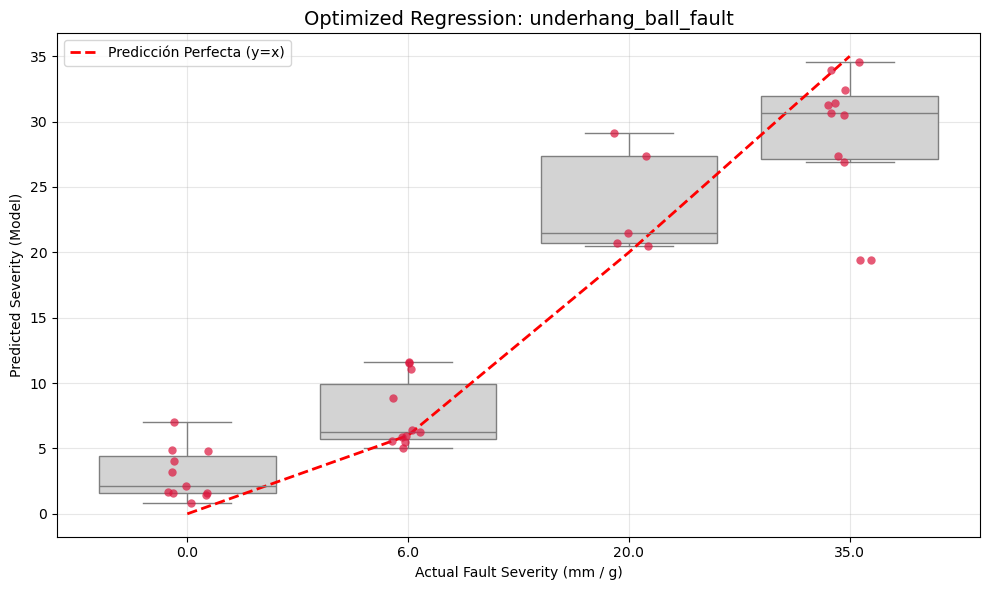

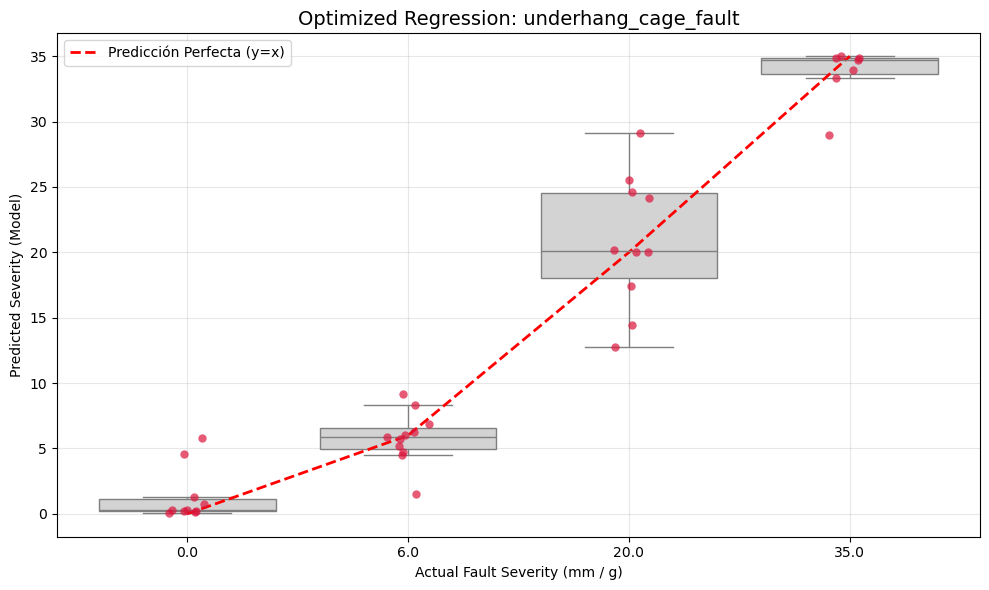

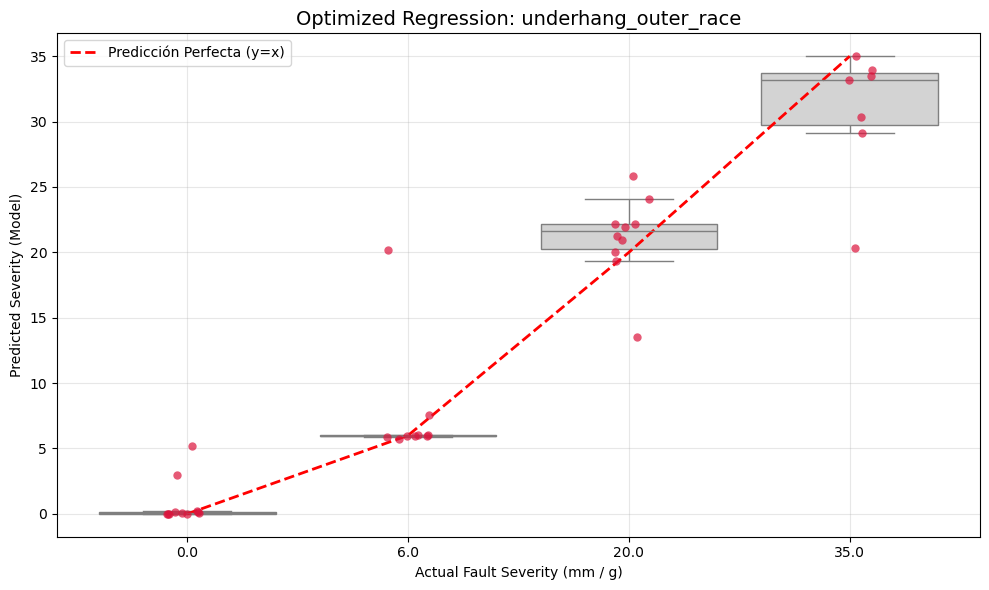

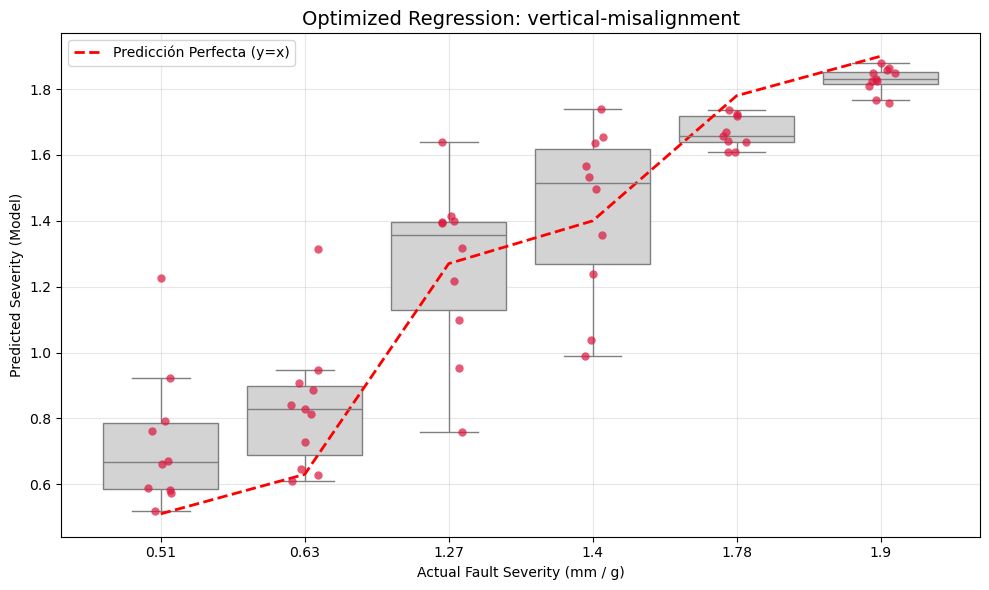

=== EVALUACIÓN OPTIMIZADA: MODELO HÍBRIDO ===


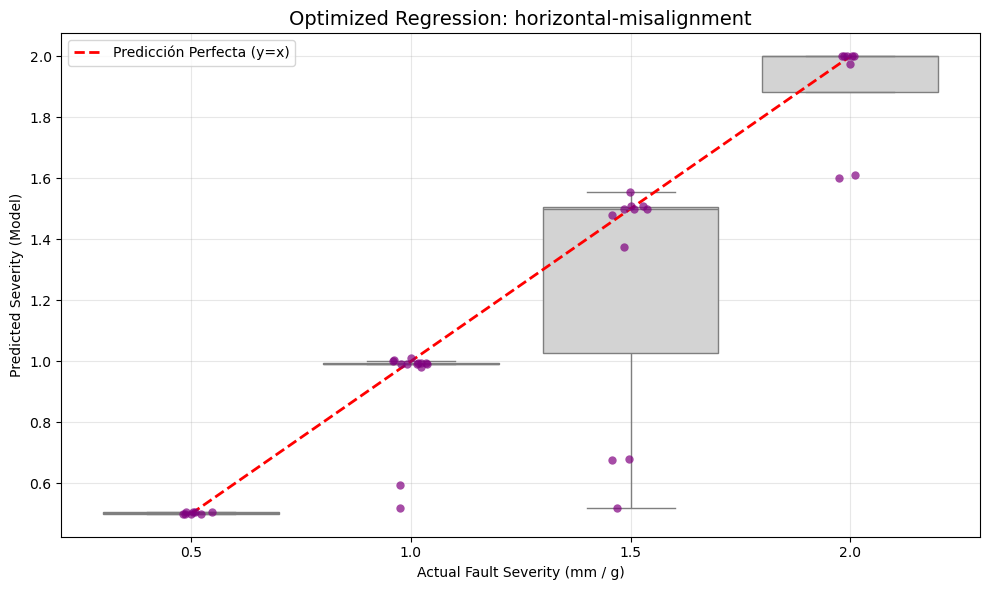

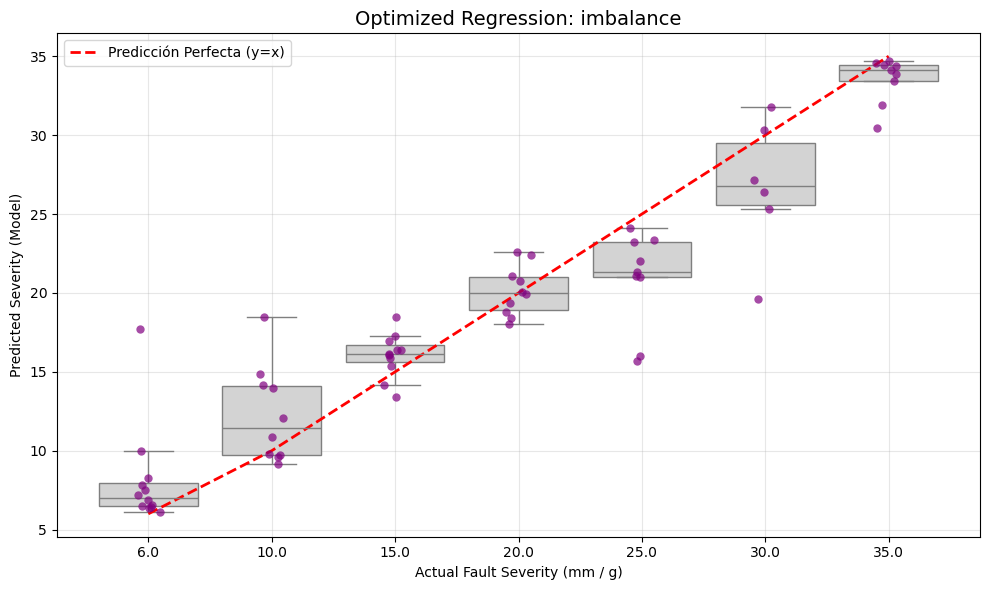

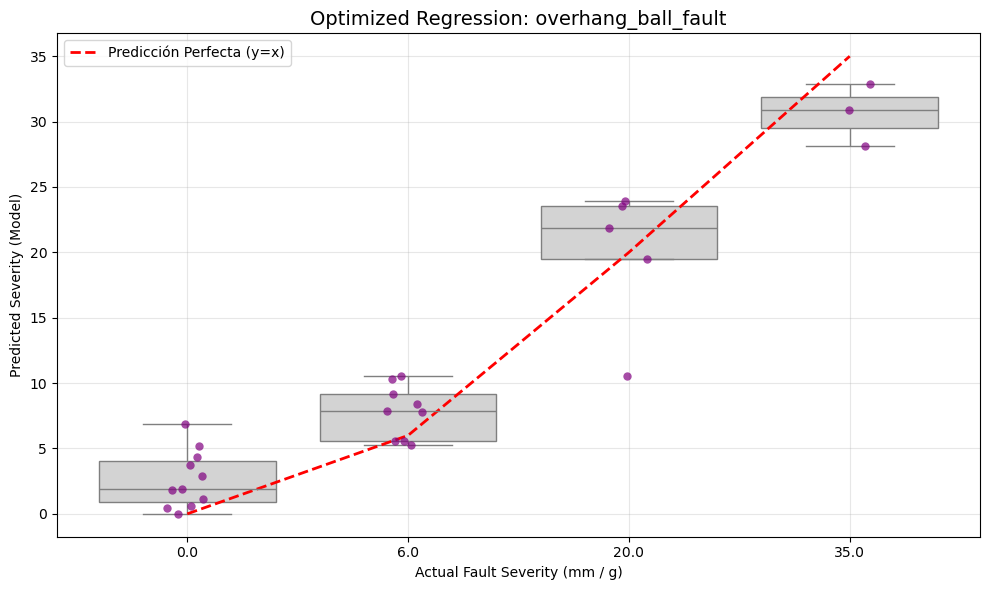

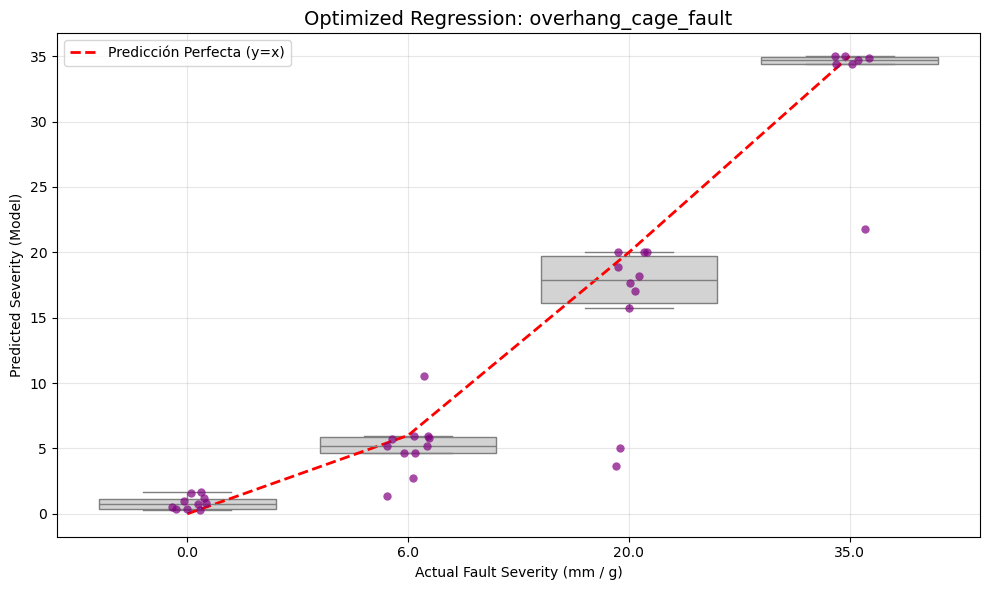

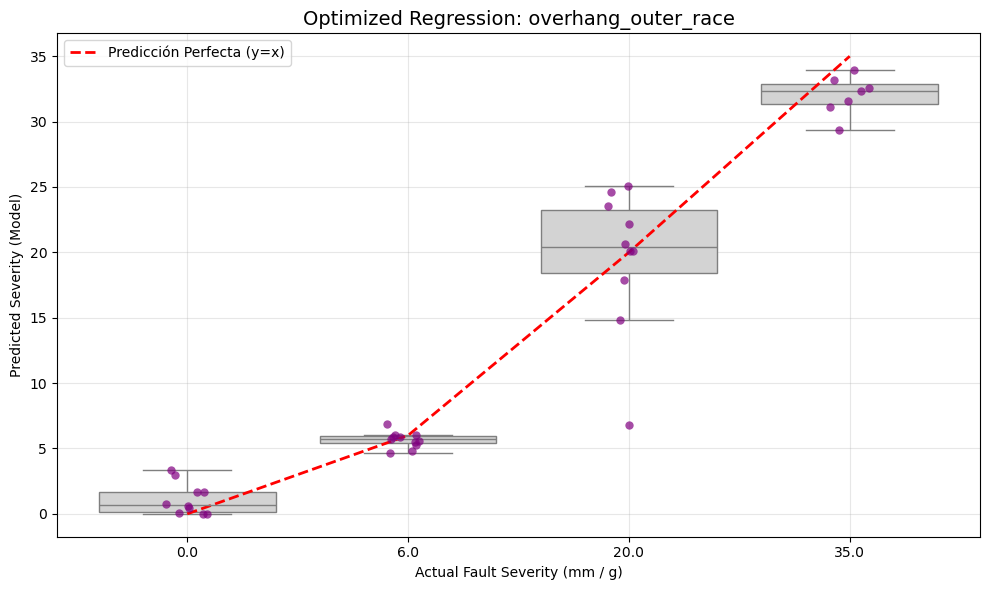

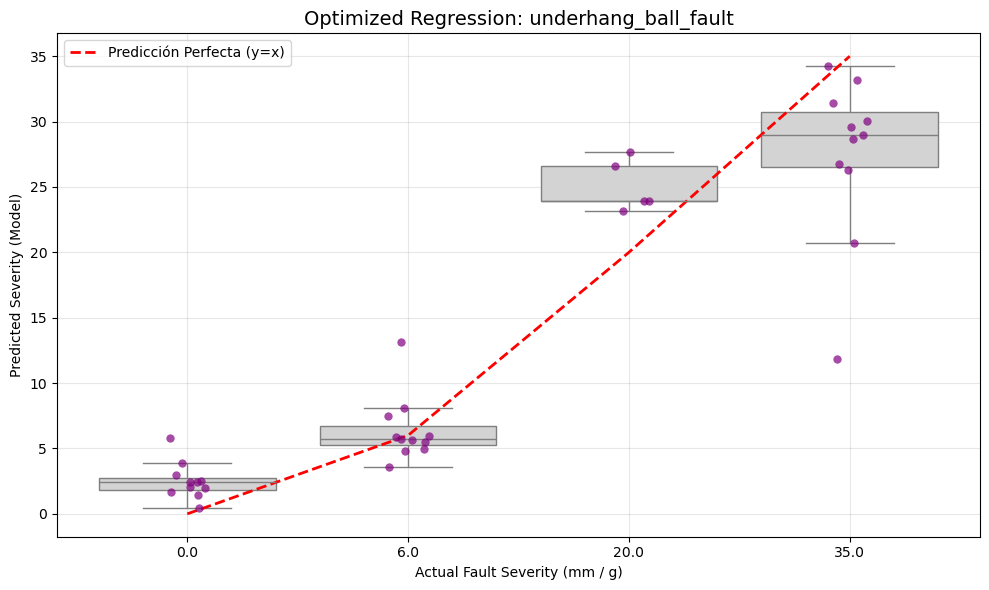

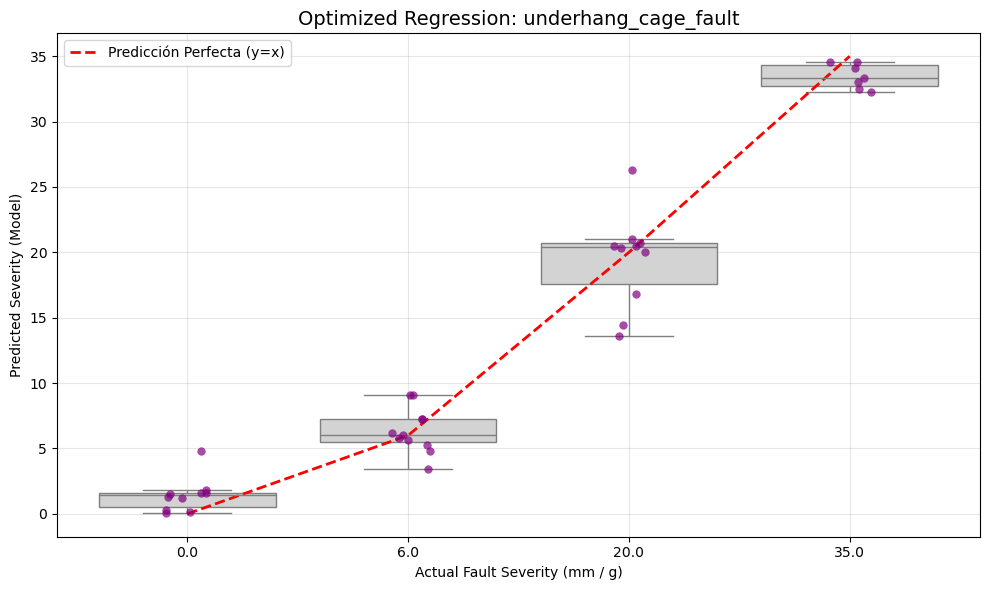

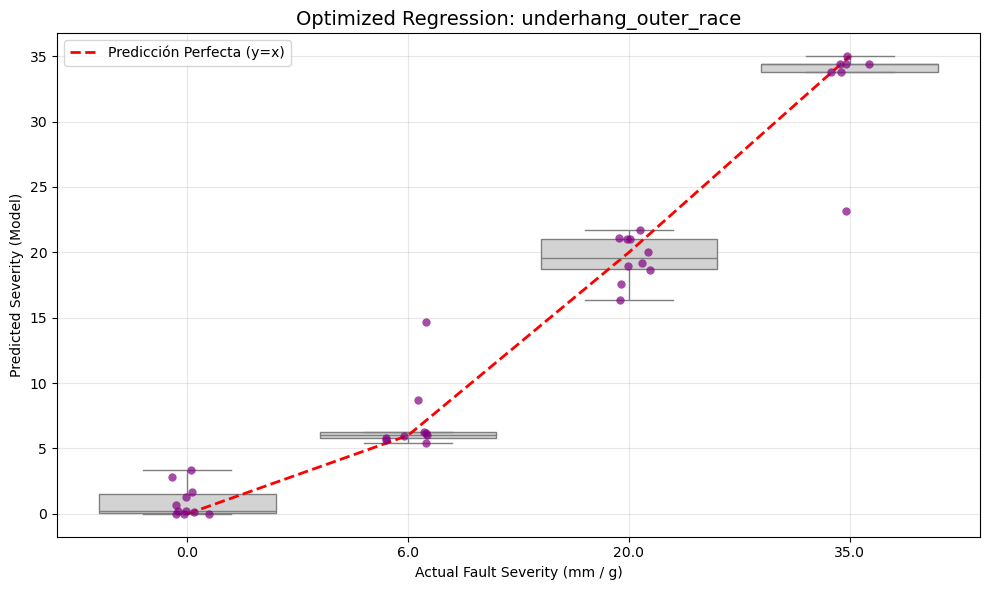

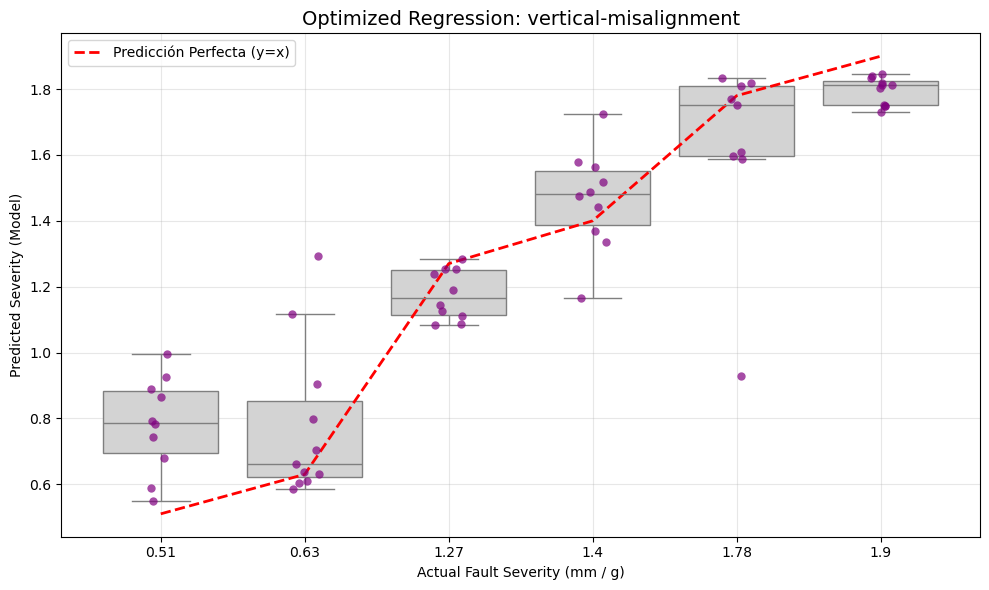

In [6]:
# --- 3. VALIDACIÓN DEL SISTEMA OPTIMIZADO (REGRESIÓN ESPECIALISTA) ---
output_dir = "../../Datos/Transformados/Modelos_subclase/best_variables"
os.makedirs(output_dir, exist_ok=True)

def entrenar_y_visualizar_regresores_optimizados(df, dominio, color_puntos):
    df_copy = df.copy()
    
    # 1. Limpieza segura de la variable objetivo (evita el AttributeError)
    df_copy['subclase'] = df_copy['subclase'].astype(str).str.replace('g', '').str.replace('mm', '').astype(float)
    
    # 2. AQUÍ ESTÁ LA SOLUCIÓN AL ERROR: Inicializamos el diccionario
    metricas = {}
    
    for clase in df_copy['clase'].unique():
        if clase == 'normal': continue
        
        df_clase = df_copy[df_copy['clase'] == clase]
        X = df_clase.drop(columns=['clase', 'subclase', 'file_path'])
        y = df_clase['subclase']
        
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
        
        modelo = RandomForestRegressor(n_estimators=100, random_state=42)
        modelo.fit(X_train, y_train)
        
        joblib.dump(modelo, os.path.join(output_dir, f"opt_{dominio}_{clase}_regressor.pkl"))
        y_pred = modelo.predict(X_test)
        
        mse = mean_squared_error(y_test, y_pred)
        
        # Guardamos en el diccionario que acabamos de crear
        metricas[clase] = {'MSE': mse, 'RMSE': mse ** 0.5, 'MAE': mean_absolute_error(y_test, y_pred), 'R2': r2_score(y_test, y_pred)}
        
        # --- GRÁFICA PROFESIONAL ---
        plt.figure(figsize=(10, 6))
        y_test_rounded = np.round(y_test, 2)
        
        sns.boxplot(x=y_test_rounded, y=y_pred, color='lightgray', showfliers=False)
        sns.stripplot(x=y_test_rounded, y=y_pred, color=color_puntos, alpha=0.7, jitter=True, size=6)
        
        valores_unicos = np.sort(np.unique(y_test_rounded))
        x_ticks = np.arange(len(valores_unicos))
        plt.plot(x_ticks, valores_unicos, '--r', linewidth=2, label='Predicción Perfecta (y=x)')
        
        plt.xlabel('Actual Fault Severity (mm / g)')
        plt.ylabel('Predicted Severity (Model)')
        plt.title(f'Optimized Regression: {clase}', fontsize=14)
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
        
    # Guardamos el JSON con las métricas
    with open(os.path.join(output_dir, f"metricas_optimizadas_{dominio}.json"), 'w') as f:
        json.dump(metricas, f, indent=4)

# ==========================================
# EJECUCIÓN DE LA VALIDACIÓN
# ==========================================
print("=== EVALUACIÓN OPTIMIZADA: TIEMPO ===")
entrenar_y_visualizar_regresores_optimizados(best_time_features, "Tiempo", "teal")

print("=== EVALUACIÓN OPTIMIZADA: FRECUENCIA ===")
entrenar_y_visualizar_regresores_optimizados(best_frequency_features, "Frecuencia", "crimson")

print("=== EVALUACIÓN OPTIMIZADA: MODELO HÍBRIDO ===")
entrenar_y_visualizar_regresores_optimizados(best_hybrid_features, "Hibrido", "purple")